In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Positional Information

Attention treats its input as a set. Every mechanism in this chapter so far —
scoring, masking, heads — computes with query–key similarities, and nothing
in a dot product depends on *where* a token sits in its sequence. For
language this is disqualifying: "dog bites man" and "man bites dog" contain
the same tokens. This section first sharpens the deficiency into a one-line
theorem, then works through the repairs in the order the field adopted them:
*adding* position vectors to the input (sinusoidal and learned encodings),
*rotating* queries and keys by position-dependent angles (RoPE, the scheme in
essentially every current open-weights model), and *biasing* attention scores
by distance (ALiBi), or trusting the causal mask to leak position on its own
(NoPE). What separates these schemes in practice is not accuracy at the
training length but *extrapolation*: what happens when a model trained at one
context length is asked to run at a longer one. To answer that question
experimentally we build this chapter's shared workhorse, a character-level
language model in which attention is the only trainable machinery that mixes
information across positions, and train it five times, once per positional
scheme.

In [1]:
%matplotlib inline
from d2l import jax as d2l
from flax import nnx
import jax
from jax import numpy as jnp
import math
import optax

## Attention Ignores Order

Let $\mathbf{X} \in \mathbb{R}^{n \times d}$ hold a sequence of $n$ token
representations and let $f$ be an (unmasked) self-attention layer,

$$
f(\mathbf{X}) = \mathrm{softmax}\!\left(\frac{\mathbf{X}\mathbf{W}_q (\mathbf{X}\mathbf{W}_k)^\top}{\sqrt{d}}\right) \mathbf{X}\mathbf{W}_v.
$$

**Proposition (permutation equivariance).** For every permutation matrix
$\boldsymbol{\Pi}$, $\;f(\boldsymbol{\Pi} \mathbf{X}) = \boldsymbol{\Pi}
f(\mathbf{X})$.

**Proof.** The projections act on each row separately, so
$(\boldsymbol{\Pi}\mathbf{X})\mathbf{W} = \boldsymbol{\Pi}(\mathbf{X}\mathbf{W})$
for each of $\mathbf{W}_q, \mathbf{W}_k, \mathbf{W}_v$. The score matrix
becomes $\boldsymbol{\Pi} \mathbf{S} \boldsymbol{\Pi}^\top$, and since softmax
normalizes each row by itself, it commutes with row and column permutations:
$\mathrm{softmax}(\boldsymbol{\Pi} \mathbf{S} \boldsymbol{\Pi}^\top) =
\boldsymbol{\Pi}\, \mathrm{softmax}(\mathbf{S})\, \boldsymbol{\Pi}^\top$.
Multiplying by the permuted values,
$\boldsymbol{\Pi}\, \mathrm{softmax}(\mathbf{S})\, \boldsymbol{\Pi}^\top
\boldsymbol{\Pi} \mathbf{X}\mathbf{W}_v = \boldsymbol{\Pi} f(\mathbf{X})$
because $\boldsymbol{\Pi}^\top \boldsymbol{\Pi} = \mathbf{I}$. Concatenating
heads and applying $\mathbf{W}_o$ row-wise preserves the property, so it
holds for multi-head attention too. $\blacksquare$

Shuffle the input, and the output shuffles along: each token's output is
unchanged, only relabeled by the permutation, so nothing the layer computes
depends on where in the sequence a token sits. The claim is easy to check
on the multi-head layer of that section:

In [2]:
attention = d2l.MultiHeadAttention(num_hiddens=64, num_heads=4, dropout=0)
X = jax.random.normal(jax.random.key(0), (1, 8, 64))
perm = jax.random.permutation(jax.random.key(1), 8)
Y = attention(X, X, X, None)[0]
Y_perm = attention(X[:, perm], X[:, perm], X[:, perm], None)[0]
print(f'max |Y[perm] - Y_perm|: {jnp.abs(Y[:, perm] - Y_perm).max():.2e}')

max |Y[perm] - Y_perm|: 0.00e+00


Two caveats frame everything that follows. First, equivariance is a property
of the *layer*; stacking equivariant layers and reading out per token leaves
the model equivariant, so depth does not help. Second, the proposition is
about unmasked attention: a causal mask singles out each position by how many
predecessors it may see, which breaks the symmetry — a loophole we return to
at the end of this section. The mainstream remedy is more direct: tell every
token where it is.

## Absolute Position Embeddings

The original transformer attaches a *position vector* $\mathbf{p}_i \in
\mathbb{R}^d$ to each position $i$ and feeds $\mathbf{x}_i + \mathbf{p}_i$
into the first layer [@Vaswani.Shazeer.Parmar.ea.2017]. Two tokens with
identical embeddings at different positions now enter attention as different
vectors, and the equivariance proof fails at its first step. The two classic
choices of $\mathbf{P}$ differ in whether the table is designed or learned.

### Sinusoidal Encodings

The designed choice fills row $i$ of $\mathbf{P} \in \mathbb{R}^{n \times d}$
with sines and cosines of geometrically spaced frequencies,

$$
p_{i, 2j} = \sin\left(\frac{i}{10000^{2j/d}}\right), \qquad p_{i, 2j+1} = \cos\left(\frac{i}{10000^{2j/d}}\right).
$$

The design looks arbitrary until you plot it. We implement the table as a
small function and look at four adjacent columns:

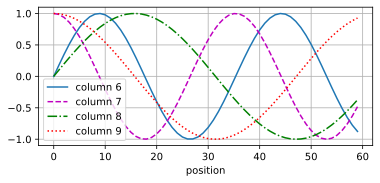

In [3]:
def sinusoidal_encoding(max_len, num_hiddens):
    theta = jnp.arange(max_len)[:, None] / 10000 ** (
        jnp.arange(0, num_hiddens, 2) / num_hiddens)
    return jnp.stack([jnp.sin(theta), jnp.cos(theta)],
                     -1).reshape(max_len, num_hiddens)

P = sinusoidal_encoding(60, 32)
d2l.plot(jnp.arange(60), P[:, 6:10].T, xlabel='position',
         figsize=(6, 2.5), legend=[f'column {d}' for d in range(6, 10)])

Adjacent column pairs share a frequency (one sine, one cosine), and the
frequency falls as the column index grows. This is a continuous version of
something familiar: binary counting. In the binary representations below, the
lowest bit flips every number, the next every two numbers, the next every
four — fast dimensions distinguish neighbors, slow dimensions distinguish
regions:

In [4]:
for i in range(8):
    print(f'{i} in binary is {i:>03b}')

0 in binary is 000
1 in binary is 001
2 in binary is 010
3 in binary is 011
4 in binary is 100
5 in binary is 101
6 in binary is 110
7 in binary is 111


The heatmap of the whole table shows the same structure in continuous form:
each row is a unique multi-frequency fingerprint of its position, and unlike
bits, the values vary smoothly, so nearby positions get nearby encodings.

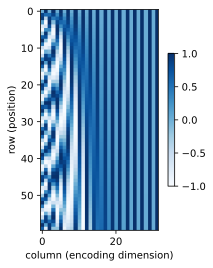

In [5]:
d2l.show_heatmaps(P[None, None], xlabel='column (encoding dimension)',
                  ylabel='row (position)', figsize=(3.5, 4), cmap='Blues')

### Learned Positions

The empirical choice is to make $\mathbf{P}$ a trainable embedding table, one
free vector per position, as in BERT and GPT-2
[@Devlin.Chang.Lee.ea.2018; @Radford.Wu.Child.ea.2019]. It concedes that
we do not know the right encoding and lets gradient descent find one. The
concession has a price we can state before running anything: the table has
exactly as many rows as the training context, and a row that no training
example ever used is still whatever initialization left there. Position 500
is not "a bit beyond position 128"; it is undefined.

### The Rotation Hidden in the Sinusoids

Why prefer designed sinusoids over a learned table at all? The original paper
offers a hypothesis: they might let the model attend by *relative* position,
"since for any fixed offset $\delta$, $\mathbf{p}_{i+\delta}$ is a linear
function of $\mathbf{p}_i$". Let's verify this and, more importantly, see
what the linear function is. Write $\omega_j = 1/10000^{2j/d}$ for the
frequency shared by columns $2j$ and $2j{+}1$. Then

$$
\begin{bmatrix} \cos(\delta \omega_j) & \sin(\delta \omega_j) \\  -\sin(\delta \omega_j) & \cos(\delta \omega_j) \\ \end{bmatrix}
\begin{bmatrix} p_{i, 2j} \\  p_{i, 2j+1} \\ \end{bmatrix}
= \begin{bmatrix} \sin\left((i+\delta) \omega_j\right) \\  \cos\left((i+\delta) \omega_j\right) \\ \end{bmatrix}
= \begin{bmatrix} p_{i+\delta, 2j} \\  p_{i+\delta, 2j+1} \\ \end{bmatrix},
$$

by the angle-addition identities. The map from position $i$ to position
$i + \delta$ is a *rotation* of each two-column pair, by an angle $\delta
\omega_j$ that depends only on the offset $\delta$, never on $i$. So the
machinery for relative positions is present in the encoding — but only
implicitly. The model receives $\mathbf{x}_i + \mathbf{p}_i$ and must *learn*
projections that exploit the rotation structure, and the additive mix is
noisy: a query–key product of two sums expands into four terms, of which only
the position–position term carries the clean rotation. If rotations by
relative offsets are what we want attention to see, why not apply them
directly where the comparison happens?

## Rotary Position Embeddings

That question, taken seriously, produces the positional scheme of nearly
every current open-weights language model — Llama, Qwen, DeepSeek, and the
rest. *Rotary position embeddings* (RoPE) [@Su.Lu.Pan.ea.2021] skip the
addition and instead act on queries and keys at the point where they meet:
the score. We want a transformation $\mathbf{R}_i$, applied to the query at
position $i$ and the key at position $j$, such that the score depends only on
the content vectors and the offset $j - i$:

$$
(\mathbf{R}_i \mathbf{q})^\top (\mathbf{R}_j \mathbf{k}) = \mathbf{q}^\top \mathbf{R}_i^\top \mathbf{R}_j \mathbf{k} \overset{!}{=} \mathbf{q}^\top \mathbf{R}_{j-i} \mathbf{k}.
$$

The requirement $\mathbf{R}_i^\top \mathbf{R}_j = \mathbf{R}_{j-i}$ says the
$\mathbf{R}_i$ form a one-parameter group of orthogonal maps — which is
exactly what planar rotations are. So RoPE recycles the sinusoidal
frequencies $\omega_m$, but *multiplicatively*: split the $d$ query
dimensions into $d/2$ pairs, and rotate pair $m$ of the position-$i$ query by
the angle $i\,\omega_m$ (and likewise for keys),

$$
\mathbf{R}_i = \begin{bmatrix} R(i\omega_0) & & \\ & \ddots & \\ & & R(i\omega_{d/2-1}) \end{bmatrix}, \qquad R(\alpha) = \begin{bmatrix} \cos\alpha & -\sin\alpha \\ \sin\alpha & \cos\alpha \end{bmatrix}.
$$

the figure shows one pair plane: shifting both positions by
the same amount rotates query and key *together*, so the angle between them —
and with it the dot product — never changes. Position vanishes from the
score except through the offset. Two further properties come free: rotations
preserve norms, so RoPE never inflates or shrinks a token's content, and the
geometric frequency ladder means low-frequency pairs rotate only slightly
across a sentence while high-frequency pairs discriminate neighboring
positions sharply — every pair carries content; the ladder only sets how
fast position turns it. Only queries and keys are rotated; values pass
through untouched. (Learned *relative*-position embeddings
[@shaw2018self; @huang2018music] pursued the same goal by adding trained
offset vectors into the score; RoPE gets it with no parameters at all.)

![Rotary embeddings rotate each two-dimensional feature pair of the query and the key by an angle proportional to position. Shifting both positions by the same amount — here by 3 — rotates both vectors together and leaves the angle between them, and hence the attention score, unchanged. Here $\theta$ is the pair's per-position angle and $\varphi$ the angle between the unrotated query and key.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-attention-rope-rotation.svg)

The implementation rotates the even/odd feature pairs with precomputed
sines and cosines; `offset` shifts every position by the same amount, which
we will use to test the invariance:

In [6]:
def rope(x, offset=0):
    """Rotate feature pairs of x (..., num_steps, d) by position angles."""
    d = x.shape[-1]
    pos = jnp.arange(x.shape[-2], dtype=jnp.float32) + offset
    inv_freq = 10000.0 ** (-jnp.arange(0, d, 2) / d)
    theta = pos[:, None] * inv_freq[None, :]
    cos, sin = jnp.cos(theta), jnp.sin(theta)
    x1, x2 = x[..., 0::2], x[..., 1::2]
    return jnp.stack([x1 * cos - x2 * sin,
                      x1 * sin + x2 * cos], -1).reshape(x.shape)

Now the numerical check of the equation: shift all positions
jointly, and the full score matrix must not move. For contrast, we run the
same test on the additive sinusoidal encoding, where the four-term expansion
leaves absolute position in the score:

In [7]:
T, d = 32, 64
key1, key2 = jax.random.split(jax.random.key(0))
q, k = jax.random.normal(key1, (T, d)), jax.random.normal(key2, (T, d))

scores = lambda off: rope(q, off) @ rope(k, off).T / math.sqrt(d)
for off in (1, 17, 480):
    print(f'RoPE, all positions shifted by {off:>3}: max score change '
          f'{jnp.abs(scores(off) - scores(0)).max():.1e}')

P = sinusoidal_encoding(600, d)
added = lambda off: (q + P[off:off+T]) @ (k + P[off:off+T]).T / math.sqrt(d)
print(f'additive sinusoidal, shifted by  17: max score change '
      f'{jnp.abs(added(17) - added(0)).max():.1e}')

RoPE, all positions shifted by   1: max score change 1.5e-03
RoPE, all positions shifted by  17: max score change 1.7e-03
RoPE, all positions shifted by 480: max score change 1.8e-03


additive sinusoidal, shifted by  17: max score change 3.3e+00


RoPE's scores are unchanged up to floating-point round-off (three or more
orders of magnitude below the score scale in these runs) at every shift,
including one far beyond where any additive table would end; the additive
encoding moves the scores by an amount comparable to the scores themselves.
Relative position is now a property of the *architecture*, not something the
model must discover. Whether that property survives contact with training
data — in particular, with offsets the training data never contained — is a
different question, and we now have everything needed to ask it properly.

## Train Short, Test Long

Every scheme above fixes permutation blindness at the training length. They
differ at *deployment*: contexts grow — users paste longer documents — and
retraining for every length is not an option. This subfield asks for *length
extrapolation*: train at context $L$, evaluate at $4L$, and hope perplexity
survives. Two more schemes were designed with exactly this test in mind.

### Linear Biases, and Nothing at All

*ALiBi* (attention with linear biases) [@Press.Smith.Lewis.2022]
encodes no positions at all. It instead subtracts a distance penalty from
every attention score: for query position $i$ and key position $j \leq i$
in head $h$ of $H$,

$$
\mathrm{score}_{ij} = \frac{\mathbf{q}_i^\top \mathbf{k}_j}{\sqrt{d}} - m_h\,(i - j), \qquad m_h = 2^{-8h/H}.
$$

Each head discounts far-away tokens at its own geometric rate — head 1
steeply (local view), head $H$ barely (global view); the slope formula
$2^{-8h/H}$ is the paper's choice for head counts that are powers of two,
with other $H$ interpolating the same geometric sequence. The bias depends
only on distance, so it is defined for every context length, and a distance
of 400 is merely "further" rather than "never seen". The cost is a fixed
recency prior the model cannot fully unlearn.

*NoPE* (no positional encoding) pushes the loophole from our proposition to
its logical end [@Kazemnejad.Padhi.Ramamurthy.ea.2023]: in a *causal*
model, drop positions entirely. The mask already breaks the symmetry —
position 0 attends over one token, position 100 over a hundred and one — so
the number of tokens competing in each softmax is itself positional
information, and a decoder can in principle recover relative order from it.
No table, no rotation, nothing to run out of range. The question is how much
usable position signal actually leaks through.

### An Attention-Only Language Model

Claims about extrapolation are cheap; we test them by training. The model
below — the chapter's shared specimen, reused later for a look inside
trained attention — is deliberately minimal: a token embedding, a stack of
residual causal attention blocks, and an output head tied to the embedding
[@Press.Wolf.2017]. There is no feed-forward network and no
normalization layer, and the attention projections carry no bias terms by
default (a `bias` switch restores them;
that section has one use for it): besides the
embedding table (which doubles as the output head), attention
is the only trainable machinery, and all mixing of information across
positions passes through it — which is the point, and what makes the model
exactly analyzable when we dissect it in
that section. It is the attention-only cousin of
the `TinyLM` of that section, and the positional scheme is a
constructor argument taking `'learned'`, `'sinusoidal'`, `'rope'`,
`'alibi'`, or `'none'`, implemented exactly as in the equations above.

In [8]:
class TinyCharLM(nnx.Module):
    """Attention-only character-level language model."""
    def __init__(self, vocab_size, num_hiddens=128, num_heads=4, num_blks=2,
                 pos='rope', max_len=512, bias=False, rngs=None):
        rngs = nnx.Rngs(0) if rngs is None else rngs
        self.num_heads, self.pos = num_heads, pos
        init = nnx.initializers.normal(0.02)
        self.token_emb = nnx.Embed(vocab_size, num_hiddens,
                                   embedding_init=init, rngs=rngs)
        if pos == 'learned':
            self.pos_emb = nnx.Embed(max_len, num_hiddens,
                                     embedding_init=init, rngs=rngs)
        if pos == 'sinusoidal':
            theta = jnp.arange(max_len)[:, None] / 10000 ** (
                jnp.arange(0, num_hiddens, 2) / num_hiddens)
            P = jnp.stack([jnp.sin(theta), jnp.cos(theta)], -1)
            self.P = nnx.Cache(P.reshape(max_len, num_hiddens))
        self.blks = nnx.List([nnx.Dict(
            qkv=nnx.Linear(num_hiddens, 3 * num_hiddens, use_bias=bias,
                           rngs=rngs),
            proj=nnx.Linear(num_hiddens, num_hiddens, use_bias=bias,
                            rngs=rngs))
            for _ in range(num_blks)])

    def _rope(self, x):
        d = x.shape[-1]
        pos = jnp.arange(x.shape[-2], dtype=jnp.float32)
        inv_freq = 10000.0 ** (-jnp.arange(0, d, 2) / d)
        theta = pos[:, None] * inv_freq[None, :]
        cos, sin = jnp.cos(theta), jnp.sin(theta)
        x1, x2 = x[..., 0::2], x[..., 1::2]
        return jnp.stack([x1 * cos - x2 * sin,
                          x1 * sin + x2 * cos], -1).reshape(x.shape)

    def _alibi(self, T):
        h = jnp.arange(1, self.num_heads + 1)
        slopes = 2.0 ** (-8.0 * h / self.num_heads)
        pos = jnp.arange(T, dtype=jnp.float32)
        return slopes[:, None, None] * (pos[None, :] - pos[:, None])

    def _attend(self, blk, H):
        B, T, D = H.shape
        q, k, v = jnp.split(blk['qkv'](H), 3, axis=-1)
        q, k, v = (u.reshape(B, T, self.num_heads, -1).swapaxes(1, 2)
                   for u in (q, k, v))
        if self.pos == 'rope':
            q, k = self._rope(q), self._rope(k)
        scores = q @ k.swapaxes(-2, -1) / math.sqrt(q.shape[-1])
        if self.pos == 'alibi':
            scores = scores + self._alibi(T)
        mask = jnp.triu(jnp.ones((T, T), dtype=bool), 1)
        scores = jnp.where(mask, jnp.finfo(scores.dtype).min, scores)
        weights = jax.nn.softmax(scores, axis=-1)
        out = (weights @ v).swapaxes(1, 2).reshape(B, T, D)
        return blk['proj'](out), weights

    def _embed(self, X):
        H = self.token_emb(X)
        if self.pos == 'learned':
            H = H + self.pos_emb(jnp.arange(X.shape[1]))
        if self.pos == 'sinusoidal':
            H = H + self.P[:X.shape[1]]
        return H

    def __call__(self, X):
        H = self._embed(X)
        for blk in self.blks:
            out, _ = self._attend(blk, H)
            H = H + out
        return self.token_emb.attend(H)  # Tied output head

    def attention_weights(self, X):
        """Per-block attention maps, each (batch, num_heads, T, T)."""
        H, maps = self._embed(X), []
        for blk in self.blks:
            out, weights = self._attend(blk, H)
            maps.append(weights)
            H = H + out
        return maps

### The Experiment

We train one copy per scheme on the character-level Time Machine corpus of
that section at context length 128, using the same fixed-step
training loop as that section. Each run takes well under a minute on
one GPU. The learned and sinusoidal tables are allocated out to `max_len`
positions so that longer evaluation is *possible* — but only the first 128
rows of the learned table will ever receive a gradient.

In [9]:
data = d2l.TimeMachine(batch_size=64, num_steps=128, tokenization='char',
                       num_train=100000, num_val=3000)
schemes = ('learned', 'sinusoidal', 'rope', 'alibi', 'none')
models = {}
for pos in schemes:
    model = TinyCharLM(len(data.vocab), pos=pos, rngs=nnx.Rngs(0))
    optimizer = nnx.Optimizer(model, optax.adamw(1e-3, weight_decay=0.0),
                              wrt=nnx.Param)
    losses = d2l.train_lm(model, data, optimizer, 3000)
    models[pos] = model
    print(f'{pos:>10}: final training loss {sum(losses[-100:]) / 100:.2f}')

   learned: final training loss 1.84


sinusoidal: final training loss 2.09


      rope: final training loss 1.56


     alibi: final training loss 1.96


      none: final training loss 2.25


Now the test the section has been building toward. We evaluate every model's
validation perplexity at the training context and at two and four times it,
on the same held-out text:

   learned:     6.2     18.0     31.1
sinusoidal:     7.8     17.4     38.3
      rope:     5.1     10.3     37.0
     alibi:     7.1      7.1      7.1
      none:     9.2      9.4      9.5


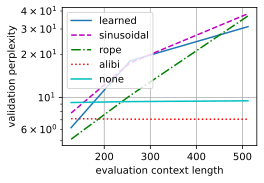

In [10]:
def eval_ppl(model, data):
    @nnx.jit
    def batch_loss(model, X, Y):
        logits = model(X)
        return optax.softmax_cross_entropy_with_integer_labels(
            logits.reshape(-1, logits.shape[-1]), Y.reshape(-1)).mean()
    losses = [float(batch_loss(model, jnp.asarray(X), jnp.asarray(Y)))
              for X, Y in data.val_dataloader()]
    return math.exp(sum(losses) / len(losses))

contexts = (128, 256, 512)
ppls = {pos: [] for pos in schemes}
for ctx in contexts:
    eval_data = d2l.TimeMachine(batch_size=16, num_steps=ctx,
                                tokenization='char', num_train=100000,
                                num_val=3000)
    for pos in schemes:
        ppls[pos].append(eval_ppl(models[pos], eval_data))
for pos in schemes:
    print(f'{pos:>10}: ' + '  '.join(f'{p:7.1f}' for p in ppls[pos]))
d2l.plot(list(contexts), [ppls[pos] for pos in schemes],
         'evaluation context length', 'validation perplexity',
         legend=list(schemes), yscale='log',
         fmts=('-', 'm--', 'g-.', 'r:', 'c-'))

Two readings of this table, both instructive. At the training context, the
ranking rewards explicit position information: RoPE comes out best at
perplexity around 5, the learned table close behind, the sinusoidal table
and ALiBi land together at around 7 — ALiBi's handicap being its fixed
recency prior — and NoPE trails at around 9. The causal mask does leak
position, but weakly at this scale. At four times the
training context, the ordering inverts. Both absolute schemes degrade badly,
to several times their training-length perplexity: the learned table because
positions past 128 are untrained noise, the sinusoidal one because the model
has never seen those fingerprints. The striking failure is RoPE: *relative in
form is not relative in practice*. Its scores depend only on offsets — we
proved and measured as much — but offsets beyond 127 were still never seen in
training, and its length-512 perplexity lands at several times its
training-length value — a blow-up as large, relative to where it started,
as the absolute schemes suffer, and in some runs far larger. Only the two
schemes with no position table are stable: ALiBi stays essentially flat
across every length, as its authors' "train short, test long" title
promised, and NoPE is flat too, just from a weaker starting point. (The
exact perplexities fluctuate run to run and between frameworks; the ordering
and the shape of the curves are what replicate.)

### Stretching a Trained Model

RoPE's failure at unseen offsets has a distinctive geometry: an offset of
400 rotates the fast pairs through angles the training data never produced.
But the rotation dial is continuous, which suggests a fix no other scheme
admits: *rescale* the angles so that the deployed range maps back into the
trained one. Evaluating at length $4L$ with every angle multiplied by $1/4$
makes position $4\delta$ look like the familiar $\delta$: interpolation
instead of extrapolation. This is *position interpolation*
[@Chen.Wong.Chen.ea.2023], which (with a brief fine-tune) extended
Llama from 2k to 32k context; YaRN [@Peng.Quesnelle.Fan.ea.2024]
refines it by rescaling the fast, position-discriminating frequencies
differently from the slow, content-carrying ones. Schemes of this family are
how every long-context RoPE model you are likely to use was produced. Note
that the recipe has two halves: rescaling *and* a brief fine-tune at the
scaled angles. Exercise 3 walks through both halves on our character model;
in our runs the rescaling alone actually hurts — compressing the angle
ladder blurs exactly the fast pairs that tell neighboring characters
apart — while rescaling followed by a few hundred fine-tuning steps
recovers most of the lost perplexity.

## Summary

Unmasked attention is permutation equivariant: shuffle the tokens and the
outputs shuffle along, which we proved in one line and verified numerically.
Absolute position embeddings restore order by adding a position vector to
each token: sinusoidal tables encode position like a continuous binary
counter, learned tables let the data pick the code but say nothing beyond
the trained length. The sinusoidal table hides a cleaner idea: shifting
positions is a rotation of feature pairs. RoPE applies that rotation
directly to queries and keys, making attention scores depend on relative
offsets by construction, the scheme of essentially every current
open-weights model. ALiBi replaces encodings with a per-head linear distance
penalty, and NoPE relies on the causal mask's leak of position. Our
train-short/test-long experiment on an attention-only character model sorted
the schemes: RoPE wins at the training length, but at four times it,
absolute encodings and RoPE alike blow up — relative form
does not imply out-of-range competence — while ALiBi and NoPE hold flat.
Position interpolation and YaRN exploit RoPE's continuous dial to map long
contexts back into the trained range. The model behind the experiment,
`TinyCharLM`, reappears later in this chapter as our specimen for studying
what trained attention heads actually compute.

## Exercises

1. Causal attention is not permutation equivariant. Demonstrate this
   numerically: apply a causal mask to the shuffle experiment of the first
   section and measure the output difference. Then explain precisely where
   the equivariance proof breaks, and why the *first* position's output is
   nevertheless unchanged by any permutation that fixes it.
2. How much position information leaks through the causal mask? Train a
   linear probe (one linear layer) to predict the position index $i$ from
   the final hidden state $\mathbf{h}_i$ of the trained `'none'` model, and
   compare its accuracy against the same probe on the `'rope'` model.
3. Implement position interpolation: add a `scale` argument to
   `TinyCharLM._rope` that multiplies every angle, and re-evaluate the
   trained `'rope'` model at context 512 with `scale=128/512`. You will
   find that zero-shot rescaling alone does not help this character-level
   model — explain why, considering what the fastest frequency pairs are
   responsible for. Then complete the published recipe: fine-tune for a few
   hundred steps at context 512 with the scaled angles, re-evaluate, and
   compare the result against the ALiBi row of the experiment.
4. The experiment adds the sinusoidal table at its classic full amplitude,
   while the token embeddings are initialized two orders of magnitude
   smaller. Scale the table by 0.02 instead, retrain, and evaluate at all
   three lengths. Explain what the model degenerates into and which row of
   the results table it now resembles.
5. RoPE's base constant sets the frequency ladder. Retrain the `'rope'`
   variant with the base changed from 10000 to 100 and to 1000000, and
   compare both training-length perplexity and extrapolation. Which
   frequencies does each change affect, and why does the base matter more
   at length 512 than at length 128?
6. Visualize `models['rope'].attention_weights(X)` for a validation batch
   and compare with the `'none'` model. Which heads attend locally, which
   uniformly? Reconcile what you see with the two models' perplexity gap at
   the training length.